In [267]:
# Import libraries with suppressed non-critical warnings
import warnings
warnings.filterwarnings('ignore', category=UserWarning)  # Cleaner output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Set Seaborn style
sns.set_style("whitegrid")

# Load data with Windows-1252 encoding (common for legacy datasets)
# Disable low_memory to prevent mixed-type warnings at cost of higher RAM usage
df = pd.read_csv('AviationData.csv', encoding='cp1252', low_memory=False)

# Quick validation: data was successfully loaded, show structure and sample
df.head()

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [268]:
#cleaning date column - converting it to datetime
df['Event.Date'] = pd.to_datetime(df['Event.Date'], errors='coerce')
#checking maximum and minimum dates to determine which dates to work with
max_date =df['Event.Date'].max()
min_date =df['Event.Date'].min()
print(f'Max_date = {max_date} \nMin_date = {min_date}')

Max_date = 2022-12-29 00:00:00 
Min_date = 1948-10-24 00:00:00


In [269]:
#extracting data with the most recent dataset for accurate analysis-last 2 decades
# Filter years between 2012 and 2022 (inclusive) 
df = df[df['Event.Date'].dt.year.between(2012, 2022)]

In [270]:
df['Engine.Type']

71225    Reciprocating
71226    Reciprocating
71227    Reciprocating
71228    Reciprocating
71229    Reciprocating
             ...      
88884              NaN
88885              NaN
88886              NaN
88887              NaN
88888              NaN
Name: Engine.Type, Length: 17664, dtype: object

In [271]:
# Display critical dataset metadata: 
# - Shape (rows/columns), 
# - Column data types, 
# - Non-null counts (missing values), 
# - Memory footprint
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17664 entries, 71225 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Event.Id                17664 non-null  object        
 1   Investigation.Type      17664 non-null  object        
 2   Accident.Number         17664 non-null  object        
 3   Event.Date              17664 non-null  datetime64[ns]
 4   Location                17664 non-null  object        
 5   Country                 17664 non-null  object        
 6   Latitude                15571 non-null  object        
 7   Longitude               15571 non-null  object        
 8   Airport.Code            10523 non-null  object        
 9   Airport.Name            10486 non-null  object        
 10  Injury.Severity         16815 non-null  object        
 11  Aircraft.damage         16437 non-null  object        
 12  Aircraft.Category       17349 non-null  object 

In [272]:
#filter the most relevant columns for our analysis
relevant_col = ['Event.Id','Event.Date','Weather.Condition','Total.Fatal.Injuries'
                ,'Total.Serious.Injuries', 'Total.Minor.Injuries','Make','Engine.Type', 
                'Broad.phase.of.flight','Aircraft.Category','Injury.Severity','Purpose.of.flight']
df = df[relevant_col]

In [273]:
(df.isnull().sum()/len(df))*100

Event.Id                    0.000000
Event.Date                  0.000000
Weather.Condition          19.185915
Total.Fatal.Injuries        0.000000
Total.Serious.Injuries      0.000000
Total.Minor.Injuries        0.000000
Make                        0.084918
Engine.Type                27.485281
Broad.phase.of.flight     100.000000
Aircraft.Category           1.783288
Injury.Severity             4.806386
Purpose.of.flight          20.006793
dtype: float64

In [274]:
#handling missing values in our critical columnss
critical_columns = ['Event.Date','Aircraft.Category','Weather.Condition','Total.Fatal.Injuries']
df = df.dropna(subset=critical_columns)

In [275]:
# Fill missing numeric injury columns with 0
injury_columns = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries']
df[injury_columns] = df[injury_columns].fillna(0)

In [276]:
# Fill missing categorical columns with 'Unknown'
categorical_columns = ['Make','Engine.Type', 'Broad.phase.of.flight', 'Injury.Severity','Purpose.of.flight']
df[categorical_columns] = df[categorical_columns].fillna('Unknown')

In [277]:
# Standardize text columns
df['Weather.Condition'] = df['Weather.Condition'].str.upper()
cols_to_title = ['Make','Engine.Type','Purpose.of.flight']  # Replace with your columns
df[cols_to_title] = df[cols_to_title].apply(lambda x: x.str.title())

In [278]:
#Assessing data quality
# determining the columns with excessive missing values that may need dropping
(df.isnull().sum()/len(df))*100

Event.Id                  0.0
Event.Date                0.0
Weather.Condition         0.0
Total.Fatal.Injuries      0.0
Total.Serious.Injuries    0.0
Total.Minor.Injuries      0.0
Make                      0.0
Engine.Type               0.0
Broad.phase.of.flight     0.0
Aircraft.Category         0.0
Injury.Severity           0.0
Purpose.of.flight         0.0
dtype: float64

In [279]:
#Creating a column to count accident
df['Accident_Count'] = 1

In [280]:
#Confirm the changes
df.head()

,Event.Id,Event.Date,Weather.Condition,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Make,Engine.Type,Broad.phase.of.flight,Aircraft.Category,Injury.Severity,Purpose.of.flight,Accident_Count
71225,20120102X93914,2012-01-01,VMC,0.0,0.0,0.0,Haney John F B,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1
71226,20120103X02043,2012-01-01,VMC,0.0,0.0,2.0,Continental Copters Inc.,Reciprocating,Unknown,Helicopter,Non-Fatal,Aerial Observation,1
71227,20111230X02532,2012-01-02,VMC,0.0,0.0,0.0,Mcadam W E,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1
71228,20120103X35104,2012-01-02,VMC,0.0,0.0,0.0,Maule,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1
71229,20120103X94513,2012-01-02,VMC,0.0,0.0,0.0,Piper,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1


In [281]:
#checking if there are duplicates
duplicate_rows = df.duplicated().sum()
duplicate_rows

3

In [282]:
#removing duplicates
df = df.drop_duplicates()

In [283]:
df.head()

,Event.Id,Event.Date,Weather.Condition,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Make,Engine.Type,Broad.phase.of.flight,Aircraft.Category,Injury.Severity,Purpose.of.flight,Accident_Count
71225,20120102X93914,2012-01-01,VMC,0.0,0.0,0.0,Haney John F B,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1
71226,20120103X02043,2012-01-01,VMC,0.0,0.0,2.0,Continental Copters Inc.,Reciprocating,Unknown,Helicopter,Non-Fatal,Aerial Observation,1
71227,20111230X02532,2012-01-02,VMC,0.0,0.0,0.0,Mcadam W E,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1
71228,20120103X35104,2012-01-02,VMC,0.0,0.0,0.0,Maule,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1
71229,20120103X94513,2012-01-02,VMC,0.0,0.0,0.0,Piper,Reciprocating,Unknown,Airplane,Non-Fatal,Personal,1


In [284]:
#to save the cleaned data in csv
df.to_csv('cleaned_aviation_data.csv', index=False, encoding='utf-8-sig')

In [285]:
# Get aircraft make with highest total fatalities and accident frequency
make_most_fatalities = df.groupby('Make').agg(
    Total_Fatalities=('Total.Fatal.Injuries', 'sum'),
    Total_Accidents=('Accident_Count', 'sum')
).sort_values('Total_Fatalities', ascending=False).head(10)

print(make_most_fatalities)

                    Total_Fatalities  Total_Accidents
Make                                                 
Cessna                         968.0             3564
Piper                          724.0             2120
Beech                          424.0              758
Bell                           146.0              350
Mooney                          94.0              193
Robinson                        85.0              149
Cirrus Design Corp              75.0              147
Vans                            48.0              106
Dehavilland                     40.0               64
Eurocopter                      38.0               61


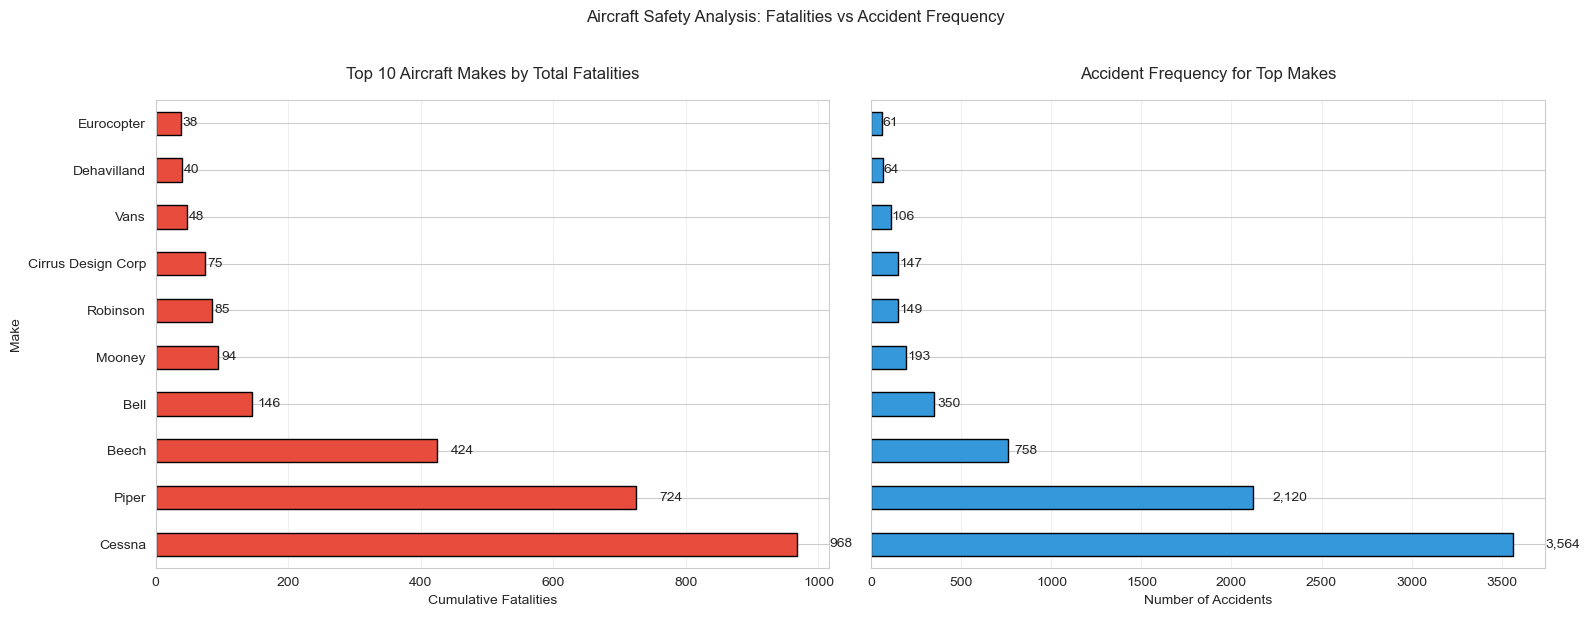

In [286]:


# Prepare data
make_stats = df.groupby('Make').agg(
    Total_Fatalities=('Total.Fatal.Injuries', 'sum'),
    Total_Accidents=('Accident_Count', 'sum')
).sort_values('Total_Fatalities', ascending=False).head(10)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Plot 1: Total Fatalities
make_stats['Total_Fatalities'].plot(
    kind='barh', 
    ax=ax1,
    color='#e74c3c',
    edgecolor='black'
)
ax1.set_title('Top 10 Aircraft Makes by Total Fatalities', pad=15)
ax1.set_xlabel('Cumulative Fatalities')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Accident Frequency
make_stats['Total_Accidents'].plot(
    kind='barh',
    ax=ax2,
    color='#3498db',
    edgecolor='black'
)
ax2.set_title('Accident Frequency for Top Makes', pad=15)
ax2.set_xlabel('Number of Accidents')
ax2.grid(axis='x', alpha=0.3)

# Add value labels to both plots
for ax in (ax1, ax2):
    for bar in ax.patches:
        width = bar.get_width()
        ax.text(width + (width*0.05), 
                bar.get_y() + bar.get_height()/2,
                f'{int(width):,}',
                va='center')

plt.suptitle('Aircraft Safety Analysis: Fatalities vs Accident Frequency', y=1.02)
plt.tight_layout()
plt.show()

In [287]:
# Get aircraft with list total fatalities (sum, not count)
make_most_fatalities = df.groupby('Make').agg(
    Total_Fatalities=('Total.Fatal.Injuries', 'sum'),
    Total_Accidents=('Accident_Count', 'sum')
    
).sort_values('Total_Fatalities', ascending=False).tail(10)

print(make_most_fatalities)

                                Total_Fatalities  Total_Accidents
Make                                                             
Guarino                                      0.0                1
Grumman Schweizer                            0.0                1
Grumman American Aviation                    0.0                1
Grumman Aircraft Cor-Schweizer               0.0                1
Grumman Acft Eng Cor                         0.0                1
Gross Michael E                              0.0                1
Grosch                                       0.0                2
Groen                                        0.0                1
Grob-Werke                                   0.0                1
Zwicker Murray R                             0.0                1


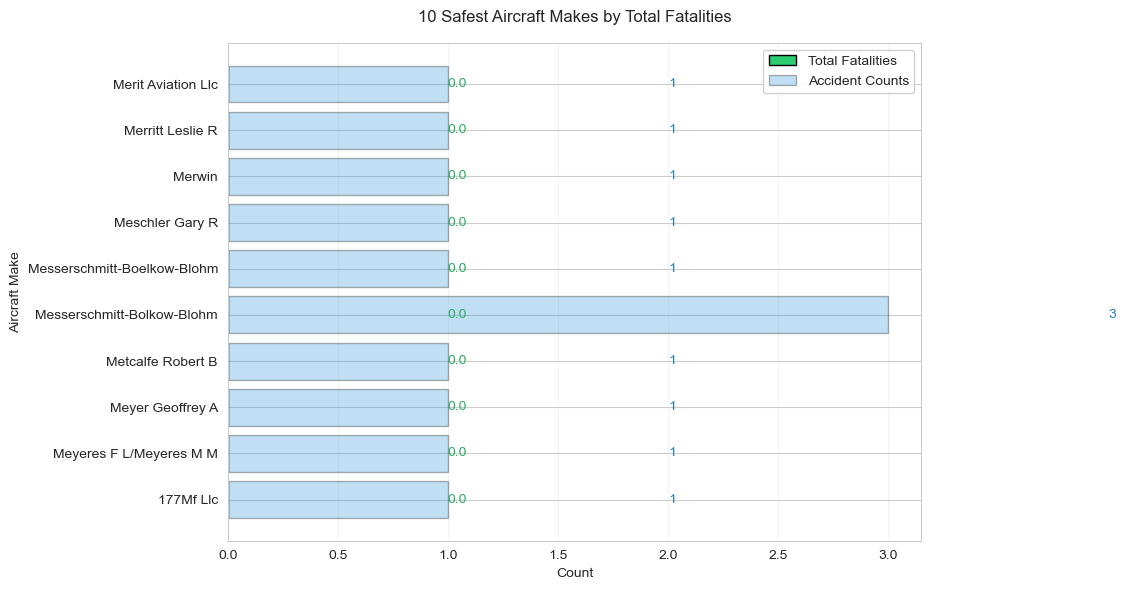

In [288]:
# Get data (lowest fatalities)
safest_makes = df.groupby('Make').agg(
    Total_Fatalities=('Total.Fatal.Injuries', 'sum'),
    Total_Accidents=('Event.Id', 'count')
).sort_values('Total_Fatalities').head(10)  # Equivalent to your .tail(10) with ascending=False

# Create figure
plt.figure(figsize=(12, 6))

# Plot fatalities (green for safe)
plt.barh(
    safest_makes.index,
    safest_makes['Total_Fatalities'],
    color='#2ecc71',
    edgecolor='black',
    label='Total Fatalities'
)

# Plot accident counts (blue)
plt.barh(
    safest_makes.index,
    safest_makes['Total_Accidents'],
    color='#3498db',
    alpha=0.3,
    edgecolor='black',
    label='Accident Counts'
)

# Formatting
plt.title('10 Safest Aircraft Makes by Total Fatalities', pad=15)
plt.xlabel('Count')
plt.ylabel('Aircraft Make')
plt.legend(frameon=True, framealpha=0.9)
plt.grid(axis='x', alpha=0.2)

# Add value labels
for i, (fatal, accid) in enumerate(zip(safest_makes['Total_Fatalities'], safest_makes['Total_Accidents'])):
    plt.text(fatal + 1, i, f"{fatal:,}", va='center', color='#27ae60')
    plt.text(accid + 1, i, f"{accid:,}", va='center', color='#2980b9')

plt.tight_layout()
plt.show()

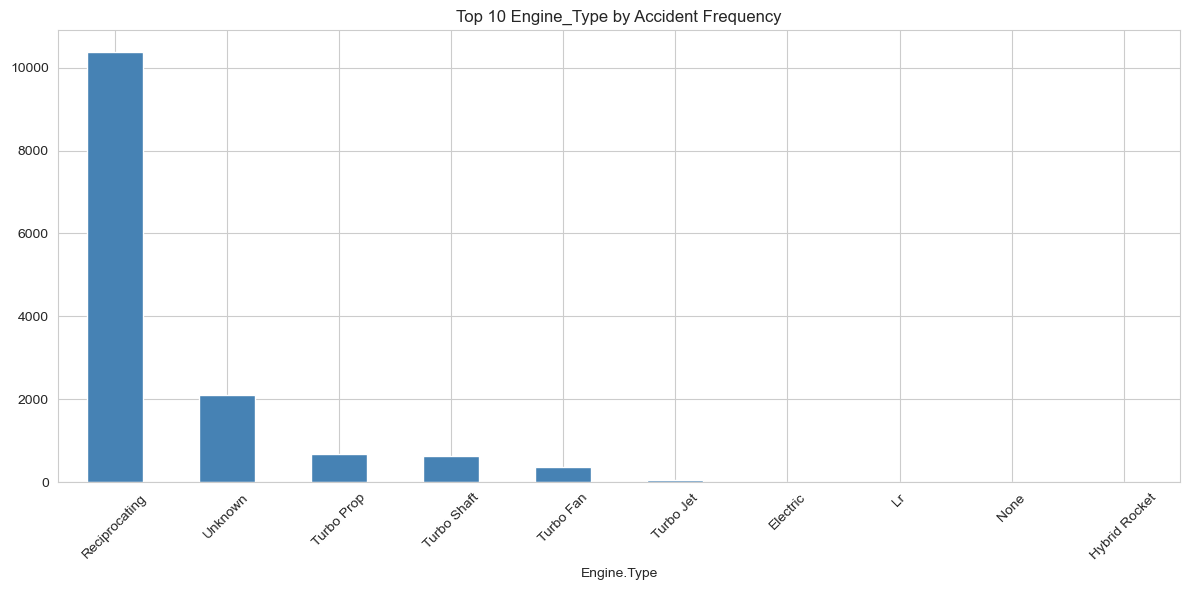

In [289]:
#top 10 most aircraft by engine type dangerous- root cause analysis
plt.figure(figsize=(12, 6))
df['Engine.Type'].value_counts().nlargest(10).plot(kind='bar', color='steelblue')
plt.title('Top 10 Engine_Type by Accident Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

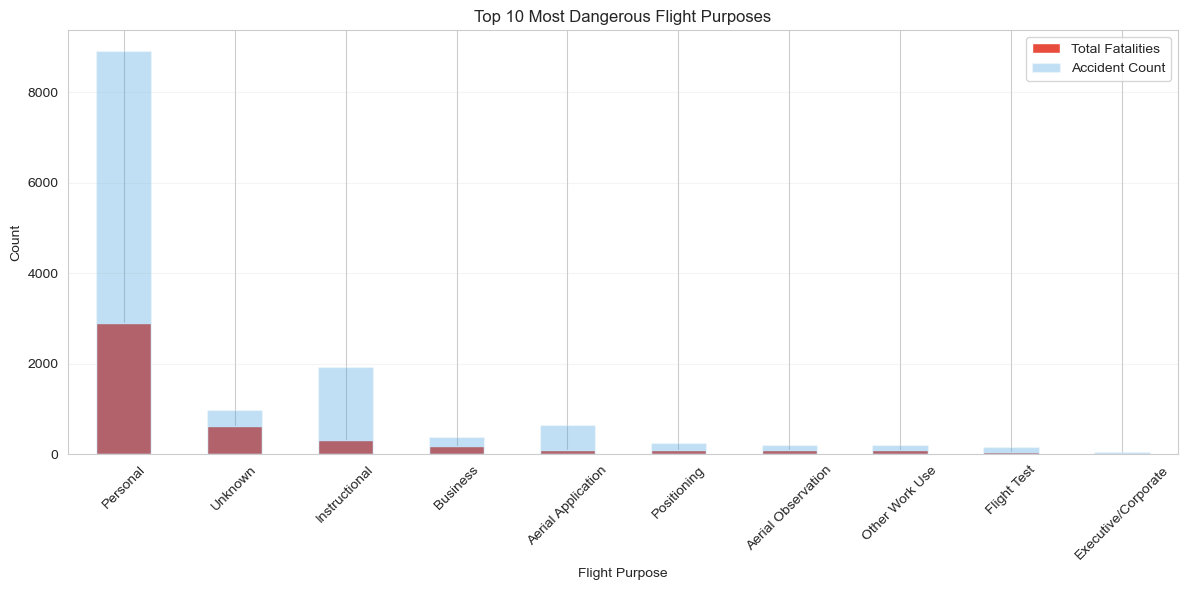

In [290]:
plt.figure(figsize=(12, 6))

# Calculate fatalities and accidents
purpose_stats = df.groupby('Purpose.of.flight').agg(
    Total_Fatalities=('Total.Fatal.Injuries', 'sum'),
    Accident_Count=('Event.Id', 'count')
).nlargest(10, 'Total_Fatalities')

# Plot
purpose_stats['Total_Fatalities'].plot(
    kind='bar', 
    color='#e74c3c',  # Red for fatalities
    label='Total Fatalities'
)

purpose_stats['Accident_Count'].plot(
    kind='bar',
    color='#3498db',  # Blue
    alpha=0.3,
    label='Accident Count'
)

# Formatting
plt.title('Top 10 Most Dangerous Flight Purposes')
plt.xlabel('Flight Purpose')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(loc='upper right')
plt.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

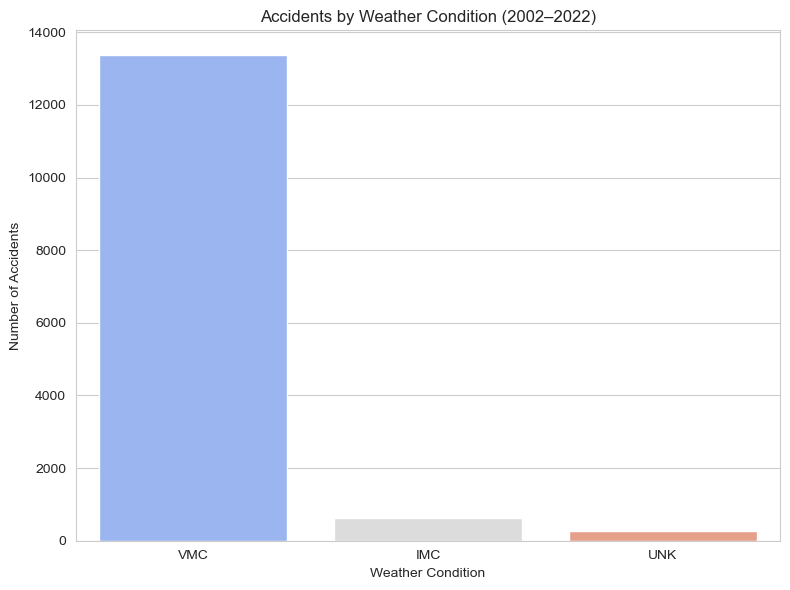

In [291]:
# 3. Accidents by Weather Condition
plt.figure(figsize=(8, 6))
sns.countplot(x='Weather.Condition', data=df, palette='coolwarm')
plt.title('Accidents by Weather Condition (2002–2022)')
plt.xlabel('Weather Condition')
plt.ylabel('Number of Accidents')
plt.tight_layout()
#plt.savefig('plots/accidents_by_weather_condition.png')
plt.show()

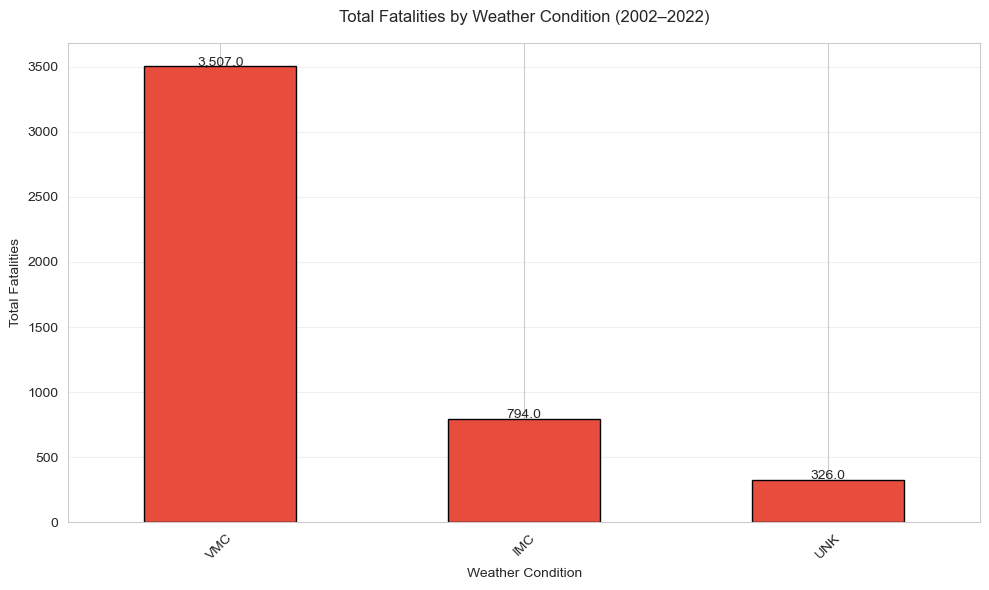

In [292]:
plt.figure(figsize=(10, 6))

# Calculate total fatalities per weather condition
weather_fatalities = df.groupby('Weather.Condition')['Total.Fatal.Injuries'].sum().sort_values(ascending=False)

# Plot
weather_fatalities.plot(kind='bar', color='#e74c3c', edgecolor='black')

plt.title('Total Fatalities by Weather Condition (2002–2022)', pad=15)
plt.xlabel('Weather Condition')
plt.ylabel('Total Fatalities')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for i, fatalities in enumerate(weather_fatalities):
    plt.text(i, fatalities + 5, f"{fatalities:,}", ha='center')

plt.tight_layout()
plt.show()

In [293]:
weather_counts = df['Weather.Condition'].value_counts()
Per_contribution = (weather_counts/weather_counts.sum())*100
Per_contribution

Weather.Condition
VMC    93.868818
IMC     4.349351
UNK     1.781831
Name: count, dtype: float64